# ROC-AUC Curve for Litigation Outcome Classifier

Visualize the classifier performance using the ROC (Receiver Operating Characteristic) curve and AUC (Area Under the Curve) metric.

## 1. Import Required Libraries

In [27]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import xgboost as xgb
from optuna.samplers import TPESampler
from sklearn.metrics import (
    auc,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split

import mlflow

# Add repo root to path
repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

## 2. Load Trained Model from MLflow

In [28]:
# Set MLflow tracking URI
mlflow.set_tracking_uri("http://localhost:5000")

print("Will train a new classifier on real case data")

Will train a new classifier on real case data


## 3. Load Real Training Data

In [29]:
# Load real training data
training_rows_path = Path("../data/processed/training_rows.csv")
df = pd.read_csv(training_rows_path)

print(f"Loaded {len(df)} cases from training_rows.csv")
print(f"Total columns: {df.shape[1]}")

# Convert outcome to binary label (1 = plaintiff win, 0 = otherwise)
df["outcome_label"] = (df["outcome"] == "plaintiff_win").astype(int)

# Select feature columns (exclude outcome and metadata columns)
exclude_cols = [
    "case_number",
    "outcome",
    "outcome_summary",
    "amount_awarded_costs",
    "amount_awarded_interest",
    "amount_awarded_principal",
    "defendant_appeared",
    "dismissal_type",
    "has_attorney_defendant",
    "has_attorney_plaintiff",
    "judgment_date",
    "missing_features",
    "claim_category",
    "outcome_label",
    "feature_version",
]

feature_cols = [col for col in df.columns if col not in exclude_cols]

# Convert all feature columns to numeric
# String 'True'/'False' becomes 1.0/0.0, NaN stays as 0
x = pd.DataFrame()
for col in feature_cols:
    if df[col].dtype == "object":
        # Convert string True/False to numeric
        x[col] = pd.to_numeric(df[col].map({"True": 1.0, "False": 0.0}), errors="coerce").fillna(
            0.0
        )
    else:
        # Already numeric
        x[col] = df[col].fillna(0.0).astype(float)

y_class = df["outcome_label"]

print(f"Feature matrix shape: {x.shape}")
print(f"Feature columns: {list(x.columns)}")
print(f"Label distribution: {y_class.value_counts().to_dict()}")

# Split into train/test
x_train, x_test, y_train, y_test = train_test_split(
    x, y_class, test_size=0.2, random_state=42, stratify=y_class
)

print(f"\nTraining set size: {len(x_train)}")
print(f"Test set size: {len(x_test)}")
print(f"Feature count: {x.shape[1]}")
print(f"Class distribution (test): {np.bincount(y_test)}")

Loaded 940 cases from training_rows.csv
Total columns: 61
Feature matrix shape: (940, 47)
Feature columns: ['argument_cites_contract_or_document', 'argument_cites_specific_dates', 'argument_cites_specific_dollar_amounts', 'argument_cites_statute_or_legal_basis', 'argument_has_chronological_timeline', 'argument_identifies_specific_location', 'argument_names_specific_witnesses', 'argument_quantifies_each_damage_component', 'attempted_mediation', 'claim_amount_is_within_small_claims_limit', 'claim_amount_stated_in_dollars', 'contract_is_signed_by_both_parties', 'contract_is_written', 'contract_present', 'contract_specifies_deadline_or_term', 'contract_specifies_payment_amount', 'counterclaim_present', 'damages_are_ongoing', 'damages_have_third_party_valuation', 'damages_include_lost_wages', 'damages_include_out_of_pocket_costs', 'damages_include_property_value_loss', 'defendant_count', 'document_count', 'gave_opportunity_to_cure', 'has_expert_assessment', 'has_invoices_or_billing_records'

## 4. Get or Train Model

In [30]:
# Define objective function for Optuna hyperparameter optimization
def objective(trial):
    """Optuna objective: maximize ROC-AUC on validation set."""
    # Hyperparameter search space
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 1),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 1),
    }

    # Train XGBoost with these params
    model = xgb.XGBClassifier(
        **params, random_state=42, verbosity=0, use_label_encoder=False, eval_metric="logloss"
    )
    model.fit(x_train, y_train, verbose=False)

    # Evaluate on test set
    y_pred_proba_val = model.predict_proba(x_test)[:, 1]
    from sklearn.metrics import roc_auc_score

    score = roc_auc_score(y_test, y_pred_proba_val)

    return score


print("Optimizing XGBoost hyperparameters with Optuna...")
sampler = TPESampler(seed=42)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=50, show_progress_bar=True)

best_params = study.best_params
best_auc = study.best_value
print(f"\n✓ Best AUC found: {best_auc:.4f}")
print(f"Best hyperparameters:\n{best_params}")

# Train final model with best parameters
print("\nTraining final XGBoost model with best hyperparameters...")
classifier = xgb.XGBClassifier(
    **best_params, random_state=42, verbosity=0, use_label_encoder=False, eval_metric="logloss"
)
classifier.fit(x_train, y_train, verbose=False)
print("✓ Model trained")

# Generate predictions
y_pred_proba = classifier.predict_proba(x_test)[:, 1]
y_pred = classifier.predict(x_test)

print(f"Predictions generated for {len(x_test)} test samples")

[I 2026-04-25 17:30:40,854] A new study created in memory with name: no-name-86729124-17db-4d44-b21c-dd3c48734598


Optimizing XGBoost hyperparameters with Optuna...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-04-25 17:30:41,039] Trial 0 finished with value: 0.541213258286429 and parameters: {'n_estimators': 144, 'max_depth': 10, 'learning_rate': 0.22227824312530747, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'gamma': 0.7799726016810132, 'min_child_weight': 1, 'reg_alpha': 0.8661761457749352, 'reg_lambda': 0.6011150117432088}. Best is trial 0 with value: 0.541213258286429.
[I 2026-04-25 17:30:41,173] Trial 1 finished with value: 0.5428392745465916 and parameters: {'n_estimators': 227, 'max_depth': 3, 'learning_rate': 0.29127385712697834, 'subsample': 0.9162213204002109, 'colsample_bytree': 0.6061695553391381, 'gamma': 0.9091248360355031, 'min_child_weight': 2, 'reg_alpha': 0.3042422429595377, 'reg_lambda': 0.5247564316322378}. Best is trial 1 with value: 0.5428392745465916.
[I 2026-04-25 17:30:41,389] Trial 2 finished with value: 0.5333333333333333 and parameters: {'n_estimators': 158, 'max_depth': 5, 'learning_rate': 0.18743733946949004, 'subsample': 0.

## 5. Calculate ROC Curve and AUC

In [31]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"False Positive Rates (first 5): {fpr[:5]}")
print(f"True Positive Rates (first 5): {tpr[:5]}")

ROC-AUC Score: 0.5704
False Positive Rates (first 5): [0.         0.00813008 0.01626016 0.01626016 0.01626016]
True Positive Rates (first 5): [0.         0.         0.01538462 0.03076923 0.06153846]


## 6. Plot the ROC-AUC Curve

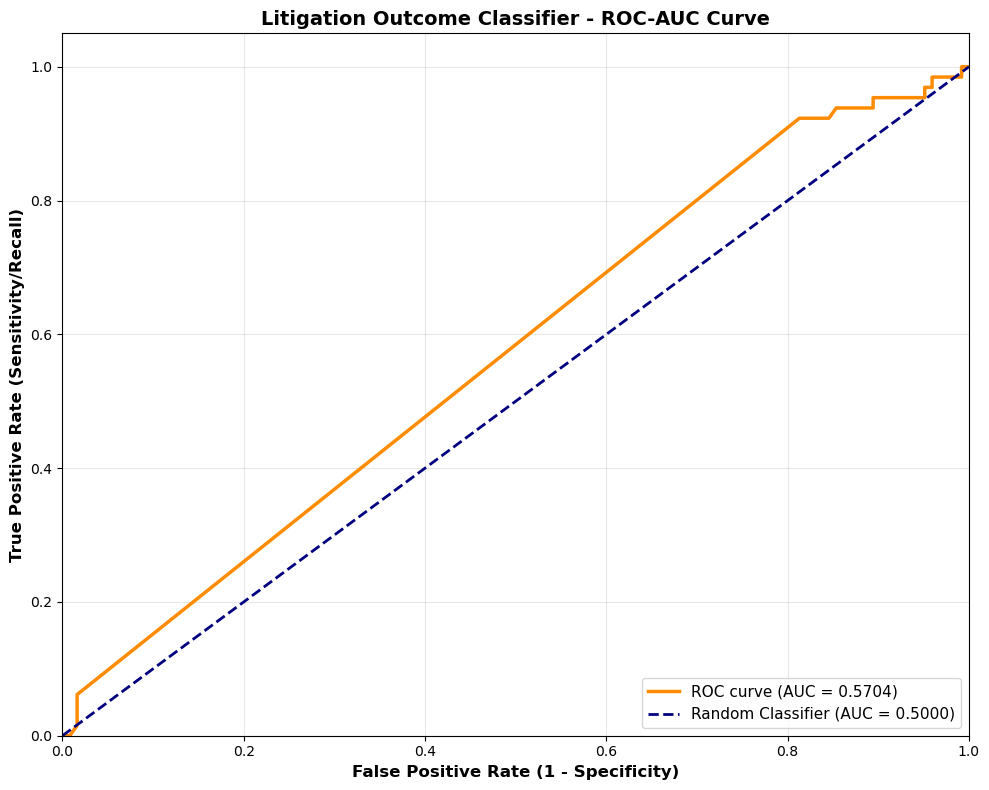


✓ ROC-AUC curve plotted successfully
  AUC Score: 0.5704


In [32]:
# Create the ROC curve plot
plt.figure(figsize=(10, 8))

# Plot the ROC curve
plt.plot(fpr, tpr, color="darkorange", lw=2.5, label=f"ROC curve (AUC = {roc_auc:.4f})")

# Plot the diagonal reference line (random classifier)
plt.plot(
    [0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random Classifier (AUC = 0.5000)"
)

# Formatting
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=12, fontweight="bold")
plt.ylabel("True Positive Rate (Sensitivity/Recall)", fontsize=12, fontweight="bold")
plt.title("Litigation Outcome Classifier - ROC-AUC Curve", fontsize=14, fontweight="bold")
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ ROC-AUC curve plotted successfully")
print(f"  AUC Score: {roc_auc:.4f}")

## 7. Display Model Performance Metrics

MODEL PERFORMANCE METRICS (XGBoost with Optuna Optimization)

Classification Metrics (Test Set):
  Accuracy:  0.6489
  Precision: 0.3333
  Recall:    0.0154
  F1-Score:  0.0294
  ROC-AUC:   0.5704

Confusion Matrix:
  True Negatives:  121
  False Positives: 2
  False Negatives: 64
  True Positives:  1

CLASSIFICATION REPORT (with Support)
                   precision    recall  f1-score   support

      Non-Win (0)     0.6541    0.9837    0.7857       123
Plaintiff Win (1)     0.3333    0.0154    0.0294        65

         accuracy                         0.6489       188
        macro avg     0.4937    0.4996    0.4076       188
     weighted avg     0.5432    0.6489    0.5242       188



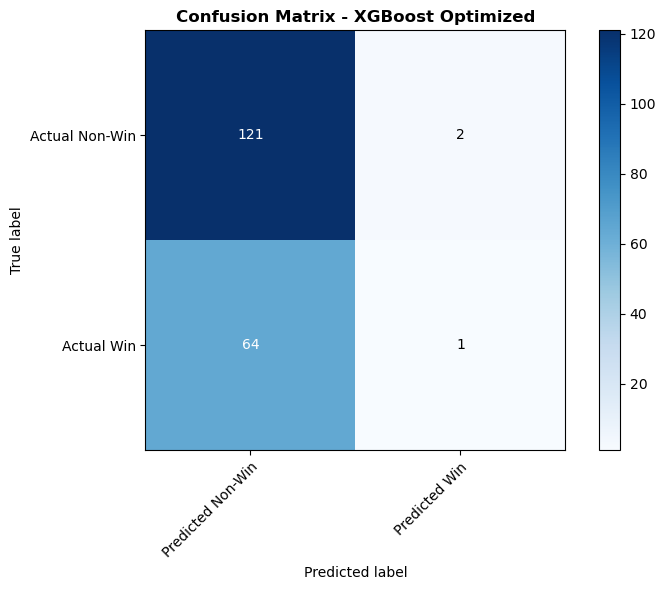

In [34]:
# Calculate additional metrics
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
cm = confusion_matrix(y_test, y_pred)

# Display metrics
print("=" * 70)
print("MODEL PERFORMANCE METRICS (XGBoost with Optuna Optimization)")
print("=" * 70)
print("\nClassification Metrics (Test Set):")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"  ROC-AUC:   {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(f"  True Negatives:  {cm[0, 0]}")
print(f"  False Positives: {cm[0, 1]}")
print(f"  False Negatives: {cm[1, 0]}")
print(f"  True Positives:  {cm[1, 1]}")

# Detailed classification report with support
print("\n" + "=" * 70)
print("CLASSIFICATION REPORT (with Support)")
print("=" * 70)
class_report = classification_report(
    y_test, y_pred, target_names=["Non-Win (0)", "Plaintiff Win (1)"], digits=4
)
print(class_report)

# Visualization of confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

# Set labels
ax.set(
    xticks=np.arange(cm.shape[1]),
    yticks=np.arange(cm.shape[0]),
    xticklabels=["Predicted Non-Win", "Predicted Win"],
    yticklabels=["Actual Non-Win", "Actual Win"],
    ylabel="True label",
    xlabel="Predicted label",
)

# Rotate labels
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Add text annotations
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            format(cm[i, j], "d"),
            ha="center",
            va="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black",
        )

ax.set_title("Confusion Matrix - XGBoost Optimized", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()